# Trading Strategies 

This chapter is about the vectorized backtesting of algorithmic trading strategies. The
term algorithmic trading strategy is used to describe any type of financial trading
strategy that is based on an algorithm designed to take long, short, or neutral posi‐
tions in financial instruments on its own without human interference. 

The chapter does not provide an overview of algorithmic trading strategies (see “Fur‐
ther Resources” on page 519 for references that cover algorithmic trading strategies in
more detail). It rather focuses on the technical aspects of the vectorized backtesting
approach for a select few such strategies

## Simple Moving Average

In [26]:
import numpy as np
import pandas as pd
import datetime as dt 
import matplotlib.pyplot as plt
import yfinance as yf 

In [ ]:
start = dt.datetime(2010,1,1)
end = dt.datetime(2018,6,29)
data = yf.download('AAPL',start,end)


[*********************100%***********************]  1 of 1 completed


In [127]:
data.columns = data.columns.droplevel(1)

In [128]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3646 entries, 2010-01-04 to 2024-06-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3646 non-null   float64
 1   High    3646 non-null   float64
 2   Low     3646 non-null   float64
 3   Open    3646 non-null   float64
 4   Volume  3646 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 170.9 KB


In [129]:
data['Close'].dropna()

Date
2010-01-04      6.406481
2010-01-05      6.417556
2010-01-06      6.315478
2010-01-07      6.303802
2010-01-08      6.345713
                 ...    
2024-06-24    206.352478
2024-06-25    207.274506
2024-06-26    211.418594
2024-06-27    212.261337
2024-06-28    208.811172
Name: Close, Length: 3646, dtype: float64

In [130]:
data

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,6.406481,6.421149,6.357686,6.389118,493729600
2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2010-01-06,6.315478,6.443003,6.308892,6.417558,552160000
2010-01-07,6.303802,6.346310,6.258000,6.338826,477131200
2010-01-08,6.345713,6.346312,6.258302,6.295422,447610800
...,...,...,...,...,...
2024-06-24,206.352478,210.873314,204.815787,205.936087,80727000
2024-06-25,207.274506,209.564665,206.818449,207.353805,55549700
2024-06-26,211.418594,213.014768,208.831009,209.683623,66213200


In [131]:
data = data.drop(columns=['Open','High','Low','Volume'])

In [133]:
Long_SMA = 200
Short_SMA = 24

In [134]:
data['S_SMA']=data['Close'].rolling(Short_SMA).mean()
data['L_SMA']=data['Close'].rolling(Long_SMA).mean()

<Axes: xlabel='Date'>

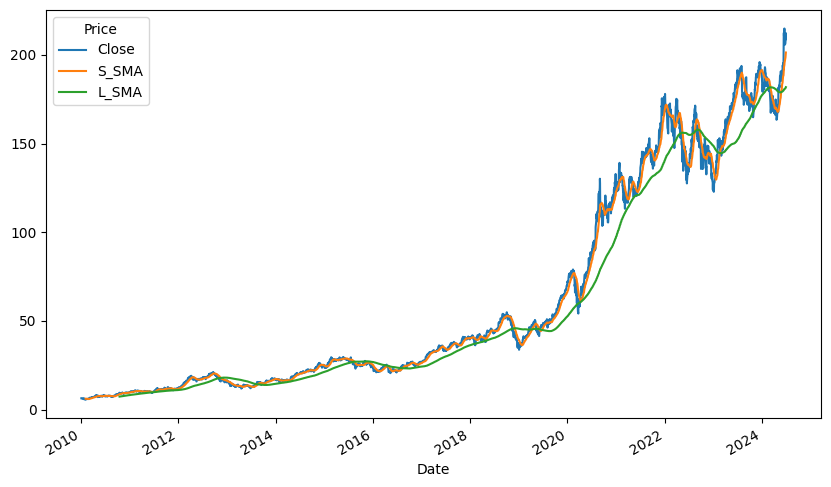

In [135]:
data.plot(figsize=(10,6))

The trading rules are:

• Go long (= +1) when the shorter SMA is above the longer SMA.

• Go short (= -1) when the shorter SMA is below the longer SMA.4


In [136]:
data.dropna(inplace=True)

np.where(cond, a, b) evaluates the condition cond element-wise and places a
when True and b otherwis

In [137]:
data['Postions']=np.where(data['S_SMA']>data['L_SMA'],1,-1)

In [138]:
data.tail()

Price,Close,S_SMA,L_SMA,Postions
Date,,,,
2024-06-24,206.352478,197.742481,181.063131,1
2024-06-25,207.274506,198.487281,181.222796,1
2024-06-26,211.418594,199.350635,181.400119,1
2024-06-27,212.261337,200.309002,181.575830,1
2024-06-28,208.811172,201.289673,181.749399,1


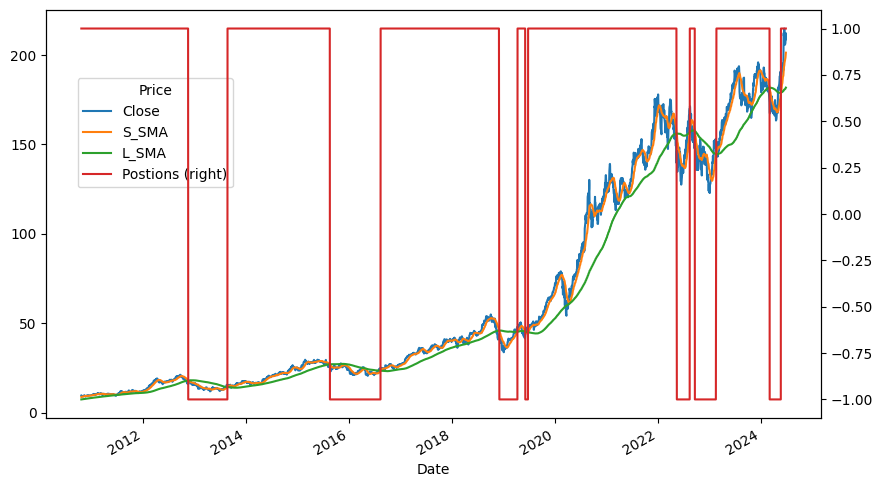

In [139]:
ax = data.plot(secondary_y='Postions',figsize=(10,6))
ax.get_legend().set_bbox_to_anchor((0.25,0.85));

### Vectorised Backtesting 

This page introduces Vectorized Backtesting, which uses numpy and pandas to calculate the entire strategy's performance across the whole dataset in just a few lines of matrix math. It is vastly faster, though slightly more prone to a specific type of error if you aren't careful.

Instead of calculating standard percentage returns $\frac{P_t - P_{t-1}}{P_{t-1}}$, quants almost exclusively use Logarithmic Returns for backtesting.The Math:$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$Why do this? Log returns are time-additive. If you want to know your total return over 5 days, you cannot simply add standard percentage returns together (due to compounding). However, you can simply sum up log returns. This makes matrix operations in Pandas incredibly fast and mathematically elegant. This column represents the "Buy and Hold" benchmark (just holding Apple stock).

In [140]:
data['Returns']=np.log(data['Close']/data['Close'].shift(1))
data['Strategy']=data['Postions'].shift(1)*data['Returns']

In [141]:
data.round(4).head()

Price,Close,S_SMA,L_SMA,Postions,Returns,Strategy
Date,,,,,,
2010-10-18,9.5195,8.6800,7.3486,1,NaN,NaN
2010-10-19,9.2647,8.7290,7.3629,1,-0.0271,-0.0271
2010-10-20,9.2958,8.7713,7.3773,1,0.0034,0.0034
2010-10-21,9.2656,8.8139,7.3920,1,-0.0033,-0.0033
2010-10-22,9.2042,8.8441,7.4065,1,-0.0066,-0.0066


In [142]:
data.dropna(inplace=True)

the script used log returns, it can simply use .sum() to add every daily return together. To convert a summed log return back into a normal, readable percentage or multiplier, you apply the exponential function $e^x$

Returns (4.017): Holding Apple turned $1 into $4.52.

Strategy (5.811): The algorithmic strategy turned $1 into $5.42.

In [143]:
np.exp(data[['Returns','Strategy']].sum())

Price
Returns     21.935170
Strategy    11.511755
dtype: float64

In finance, risk is defined as standard deviation (volatility). However, daily volatility isn't very intuitive, so quants "annualize" it to see what the volatility would be over a full year.The Math:Variance scales linearly with time, which means standard deviation (volatility) scales with the square root of time. Since there are roughly 252 trading days in a year, the formula to annualize daily volatility is:$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$(Note: In Python,  0.5 is the same as calculating the square root).

In [144]:
data[['Returns','Strategy']].std()*252**0.5

Price
Returns     0.280615
Strategy    0.280750
dtype: float64

Risk-Adjusted Outperformance.

Absolute Return: The strategy significantly beat the benchmark (5.81 vs 4.01).

Risk (Volatility): Both the strategy and the benchmark experienced the exact same annualized volatility (0.250).

Because the strategy generated higher returns without taking on any additional volatility compared to just holding the stock, it is deemed a mathematical success.

In [145]:
data

Price,Close,S_SMA,L_SMA,Postions,Returns,Strategy
Date,,,,,,
2010-10-19,9.264716,8.728959,7.362886,1,-0.027126,-0.027126
2010-10-20,9.295849,8.771317,7.377278,1,0.003355,0.003355
2010-10-21,9.265611,8.813913,7.392028,1,-0.003258,-0.003258
2010-10-22,9.204248,8.844147,7.406530,1,-0.006645,-0.006645
2010-10-25,9.245257,8.875417,7.421028,1,0.004446,0.004446
...,...,...,...,...,...,...
2024-06-24,206.352478,197.742481,181.063131,1,0.003128,0.003128
2024-06-25,207.274506,198.487281,181.222796,1,0.004458,0.004458
2024-06-26,211.418594,199.350635,181.400119,1,0.019796,0.019796


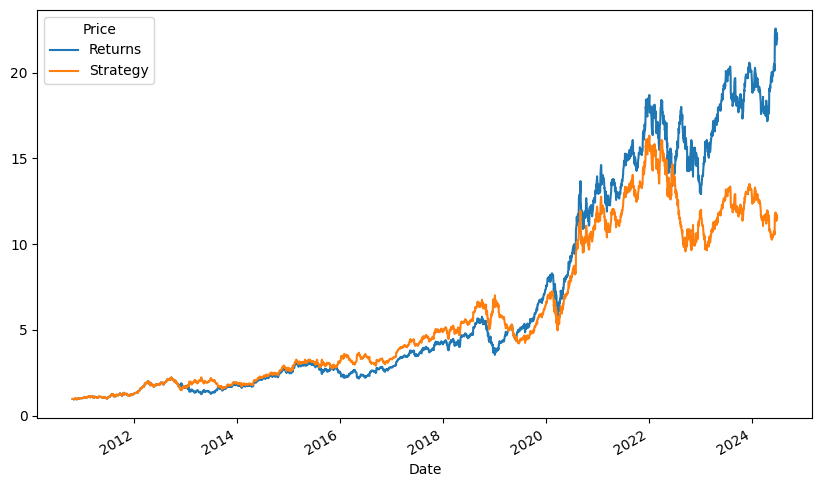

In [146]:
ax = data[['Returns','Strategy']].cumsum().apply(np.exp).plot(figsize=(10,6))

The vectorized backtesting approach as introduced in this subsec‐
tion is based on a number of simplifying assumptions. Among oth‐
ers, transactions costs (fixed fees, bid-ask spreads, lending costs,
etc.) are not included.

This might be justifiable for a trading strat‐
egy that leads to a few trades only over multiple years. 

It is also
assumed that all trades take place at the end-of-day closing prices
for the Apple stock. A more realistic backtesting approach would
take these and other (market microstructure) elements into
account.


### Optimization


A natural question that arises is if the chosen parameters SMA1=42 and SMA2=252 are
the “right” ones. In general, investors prefer higher returns to lower returns ceteris
paribus. Therefore, one might be inclined to search for those parameters that maxi‐
mize the return over the relevant period. To this end, a brute force approach can be
used that simply repeats the whole vectorized backtesting procedure for different parameter combinations, records the results, and does a ranking afterward. 

In [64]:
from itertools import product

In [156]:
start = dt.datetime(2010,1,1)
end = dt.datetime(2018,6,29)
data = yf.download('AAPL',start,end)

[*********************100%***********************]  1 of 1 completed


In [157]:
data.columns = data.columns.droplevel(1)

In [158]:
data_copy = data.drop(columns=['High','Low','Volume','Open'])

In [159]:
data_copy

Price,Close
Date,
2010-01-04,6.406480
2010-01-05,6.417557
2010-01-06,6.315477
2010-01-07,6.303801
2010-01-08,6.345712
...,...
2018-06-22,43.570045
2018-06-25,42.922108
2018-06-26,43.454597


In [160]:
sma1 = range(20,64,4)
sma2 = range(180,281,10)

In [161]:
results = pd.DataFrame()

for SMA1,SMA2 in product(sma1,sma2):
    data = data_copy.copy()
    data.dropna(inplace=True)
    data['Returns'] = np.log(data['Close']/data['Close'].shift(1))
    data['L_SMA'] = data['Close'].rolling(SMA1).mean()
    data['H_SMA'] = data['Close'].rolling(SMA2).mean()
    data.dropna(inplace=True)
    data['Postions']= np.where(data['L_SMA']>data['H_SMA'],1,-1)
    data['Strategy']=data['Postions'].shift(1) * data['Returns']
    data.dropna(inplace=True)
    perf = np.exp(data[['Returns','Strategy']].sum())
    results = pd.concat([results,pd.DataFrame(
        {
            'SMA1':SMA1, 'SMA2': SMA2,
            'MARKET': perf['Returns'],
            'STRATEGY' : perf['Strategy'],
            'OUT': perf['Strategy']-perf['Returns']
        },index=[0])],ignore_index=True)

In [162]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SMA1      121 non-null    int64  
 1   SMA2      121 non-null    int64  
 2   MARKET    121 non-null    float64
 3   STRATEGY  121 non-null    float64
 4   OUT       121 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 4.9 KB


In [163]:
results.sort_values('OUT',ascending=False).head(10)

,SMA1,SMA2,MARKET,STRATEGY,OUT
81,48,220,4.755189,6.846313,2.091124
45,36,190,5.239850,7.056093,1.816243
90,52,200,4.591299,6.336798,1.745499
50,36,240,4.558470,6.295625,1.737156
37,32,220,4.755189,6.435010,1.679822
4,20,220,4.755189,6.353211,1.598023
71,44,230,4.692375,6.267037,1.574662
5,20,230,4.692375,6.205997,1.513622
84,48,250,4.488403,5.964591,1.476189
34,32,190,5.239850,6.700716,1.460866


<Axes: xlabel='Date'>

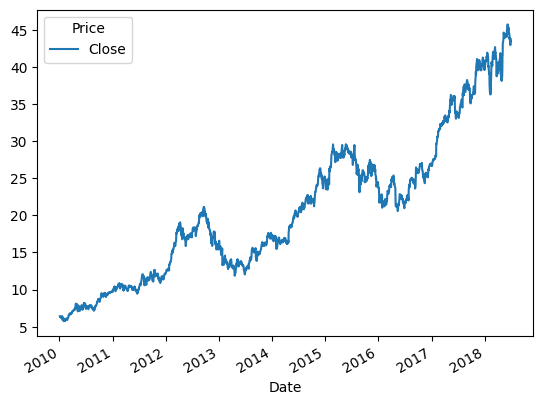

In [164]:
data_copy.plot()

#### Overfitting :- 
In general, any type of optimization, fitting, or training in the con‐
text of algorithmic trading strategies is prone to what is called over‐
fitting. This means that parameters might be chosen that perform
(exceptionally) well for the used data set but might perform
(exceptionally) badly on other data sets or in practic

## Random Walk Hypothesis 

 what the random
walk hypothesis (RWH) predicts, namely that such predictive approaches should not
yield any outperformance at all. The RWH postulates that prices in financial markets
follow a random walk, or, in continuous time, an arithmetic Brownian motion
without drift. The expected value of an arithmetic Brownian motion without drift at any point in the future equals its value today.6
 As a consequence, the best predictor
for tomorrow’s price, in a least-squares sense, is today’s price if the RWH applies.

In [169]:
symbol = 'RELIANCE.NS'

In [174]:
data = yf.download(symbol,start,end)
data.columns = data.columns.droplevel(1)
data = data.drop(columns=['Open','High','Low','Volume'])

[*********************100%***********************]  1 of 1 completed


In [175]:
data

Price,Close
Date,
2010-01-04,217.587036
2010-01-05,216.615936
2010-01-06,220.115967
2010-01-07,223.767715
2010-01-08,223.181000
...,...
2018-06-22,445.194275
2018-06-25,441.654755
2018-06-26,430.442383


In [177]:
lags = 5
cols = []
for lag in range(1,lags+1):
    col = 'lag_{}'.format(lag)
    data[col]=data['Close'].shift(lag)
    cols.append(col)

In [178]:
data.head(7)

Price,Close,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-04,217.587036,NaN,NaN,NaN,NaN,NaN
2010-01-05,216.615936,217.587036,NaN,NaN,NaN,NaN
2010-01-06,220.115967,216.615936,217.587036,NaN,NaN,NaN
2010-01-07,223.767715,220.115967,216.615936,217.587036,NaN,NaN
2010-01-08,223.181000,223.767715,220.115967,216.615936,217.587036,NaN
2010-01-11,218.800934,223.181000,223.767715,220.115967,216.615936,217.587036
2010-01-12,219.377487,218.800934,223.181000,223.767715,220.115967,216.615936


In [179]:
data.dropna(inplace=True)

In [180]:
data

Price,Close,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,
2010-01-11,218.800934,223.181000,223.767715,220.115967,216.615936,217.587036
2010-01-12,219.377487,218.800934,223.181000,223.767715,220.115967,216.615936
2010-01-13,220.237366,219.377487,218.800934,223.181000,223.767715,220.115967
2010-01-14,226.933929,220.237366,219.377487,218.800934,223.181000,223.767715
2010-01-15,224.718567,226.933929,220.237366,219.377487,218.800934,223.181000
...,...,...,...,...,...,...
2018-06-22,445.194275,453.746368,448.162231,437.961304,446.535309,445.941772
2018-06-25,441.654755,445.194275,453.746368,448.162231,437.961304,446.535309
2018-06-26,430.442383,441.654755,445.194275,453.746368,448.162231,437.961304
